In [1]:
import sys
print(sys.version)

3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
print("Setup complete")

Setup complete


In [38]:
df = pd.read_csv("credit_risk_dataset.csv")
print(df.shape)
df.head()

(32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.describe(include='all')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581,31686.000000,32581,32581,32581.000000,29465.000000,32581.000000,32581.000000,32581,32581.000000
unique,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,NaN,N,NaN
freq,NaN,NaN,16446,NaN,6453,10777,NaN,NaN,NaN,NaN,26836,NaN
mean,27.734600,6.607485e+04,NaN,4.789686,NaN,NaN,9589.371106,11.011695,0.218164,0.170203,NaN,5.804211
std,6.348078,6.198312e+04,NaN,4.142630,NaN,NaN,6322.086646,3.240459,0.413006,0.106782,NaN,4.055001
min,20.000000,4.000000e+03,NaN,0.000000,NaN,NaN,500.000000,5.420000,0.000000,0.000000,NaN,2.000000
25%,23.000000,3.850000e+04,NaN,2.000000,NaN,NaN,5000.000000,7.900000,0.000000,0.090000,NaN,3.000000
50%,26.000000,5.500000e+04,NaN,4.000000,NaN,NaN,8000.000000,10.990000,0.000000,0.150000,NaN,4.000000
75%,30.000000,7.920000e+04,NaN,7.000000,NaN,NaN,12200.000000,13.470000,0.000000,0.230000,NaN,8.000000


In [6]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(165)

# EDA

In [15]:
# Check for issues in the dataset
print("Age range:", df['person_age'].min(), "-", df['person_age'].max())
print("Max emp lenght:", df['person_emp_length'].max())

# Errors are: Ages up to 144 and emp up to 123
df_clean = df.copy()

# Remove implausible ages(>100) and emp(>60)
df_clean = df_clean[df_clean['person_age'] <= 100]
df_clean = df_clean[df_clean['person_emp_length'] <= 60]

# Handle missing emp-length with median
df_clean['person_emp_length'] = df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median())

# Loan_int_rate missing drop the column since it is not necessary
#Drop exact duplicate rows
df_clean = df_clean.drop_duplicates()

print("Cleaned shape:", df_clean.shape)
df_clean.isnull().sum()

Age range: 20 - 144
Max emp lenght: 123.0
Cleaned shape: (31522, 12)


person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3027
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [16]:
df_clean.to_csv("credit_risk_cleaned.csv", index=False)

Default rate: 21.59%


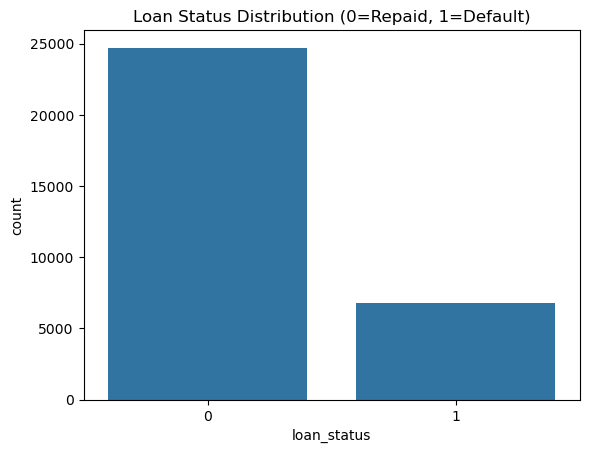

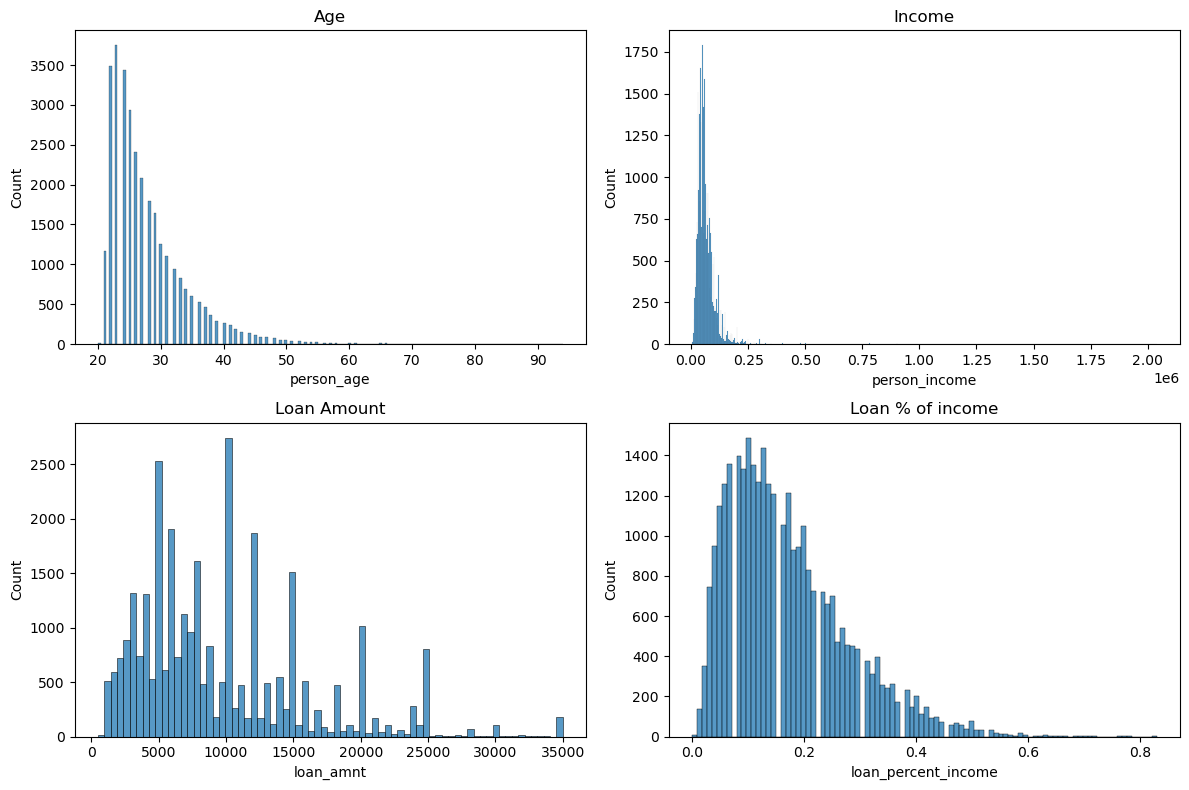

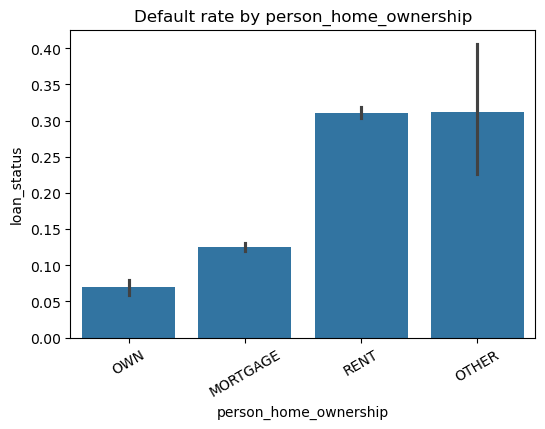

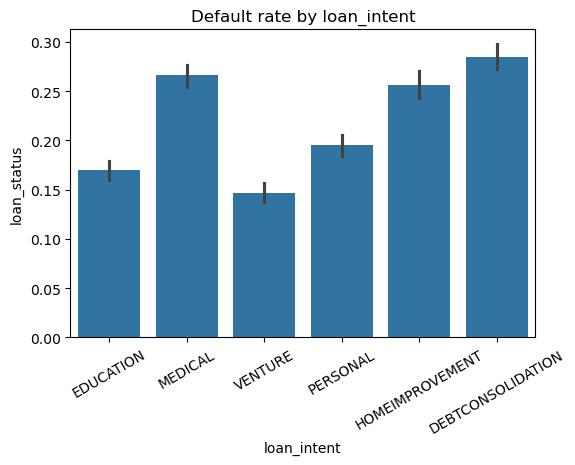

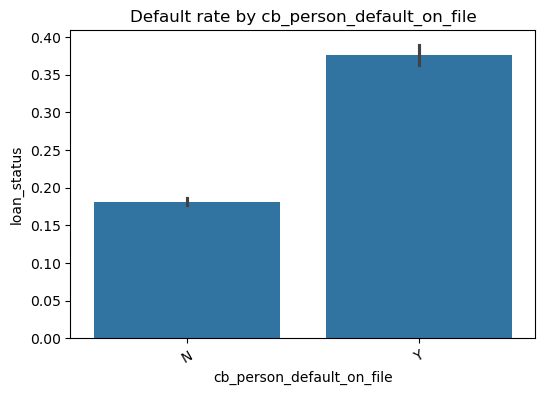

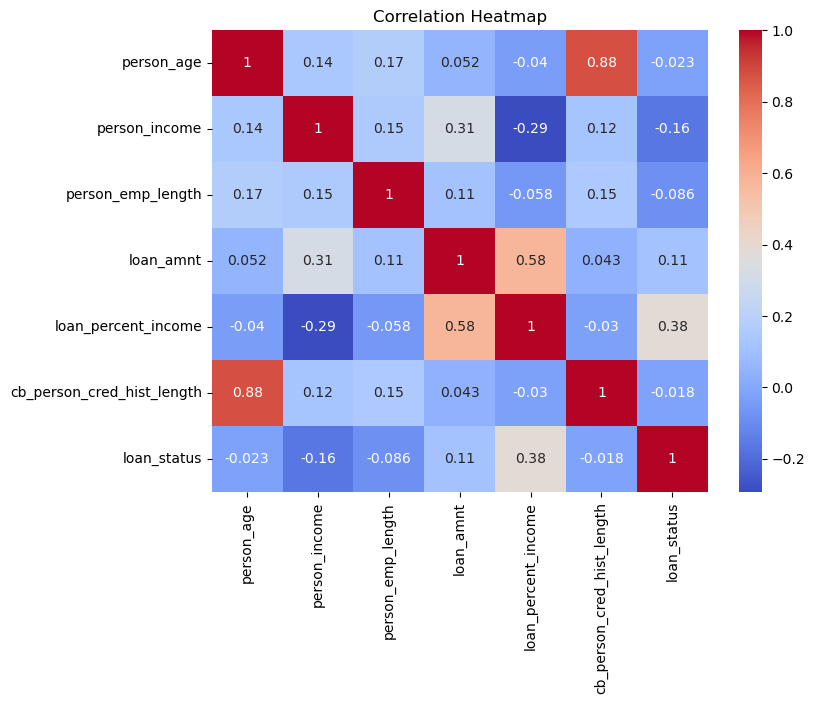

In [24]:
# Set default rate
default_rate = df_clean['loan_status'].mean()
print(f"Default rate: {default_rate:.2%}")

sns.countplot(x='loan_status', data=df_clean)
plt.title("Loan Status Distribution (0=Repaid, 1=Default)")
plt.show()

# Numeric distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df_clean['person_age'], ax=axes[0,0]).set_title("Age")
sns.histplot(df_clean['person_income'], ax=axes[0,1]).set_title("Income")
sns.histplot(df_clean['loan_amnt'], ax=axes[1,0]).set_title("Loan Amount")
sns.histplot(df_clean['loan_percent_income'], ax=axes[1,1]).set_title("Loan % of income")
plt.tight_layout()
plt.show()

# Default by categorical features
for col in ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']:
    plt.figure(figsize=(6,4))
    sns.barplot(x=col, y='loan_status', data=df_clean)
    plt.title(f"Default rate by {col}")
    plt.xticks(rotation=30)
    plt.show()

# correlation heatmap
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_status']
plt.figure(figsize=(8,6))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [25]:
print(df_clean['loan_status'].value_counts(normalize=True))

loan_status
0    0.784056
1    0.215944
Name: proportion, dtype: float64


## Feature Engineering

In [26]:
df_model = df_clean.copy()

# Debt/loan burden features
df_model['income_per_year_employed'] = df_model['person_income'] / (df_model['person_emp_length'] + 1)

# Encode binary
df_model['cb_person_default_on_file'] = df_model['cb_person_default_on_file'].map({'Y':1, 'N':0})

# Drop LEAKAGE COLUMNS 
df_model = df_model.drop(columns=['loan_grade', 'loan_int_rate'])
df_model.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,income_per_year_employed
1,21,9600,OWN,5.0,EDUCATION,1000,0,0.10,0,2,1600.000000
2,25,9600,MORTGAGE,1.0,MEDICAL,5500,1,0.57,0,3,4800.000000
3,23,65500,RENT,4.0,MEDICAL,35000,1,0.53,0,2,13100.000000
4,24,54400,RENT,8.0,MEDICAL,35000,1,0.55,1,4,6044.444444
5,21,9900,OWN,2.0,VENTURE,2500,1,0.25,0,2,3300.000000


In [28]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['loan_status'])
y = df_model['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.mean())

(25217, 10) (6305, 10)
(25217,) 0.21601903251387788


## Preprocessing Pipeline

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = ['person_age','person_income','person_emp_length','loan_amnt',
                     'loan_percent_income','cb_person_cred_hist_length',
                     'cb_person_default_on_file','income_per_year_employed']
categorical_features = ['person_home_ownership','loan_intent']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

## Baseline Models

In [30]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Dummy baseline
dummy = Pipeline([('prep', preprocessor), ('clf', DummyClassifier(strategy='most_frequent'))])
dummy.fit(X_train, y_train)
print("Dummy ROC-AUC:", roc_auc_score(y_test, dummy.predict_proba(X_test)[:,1]))

# Logistic Regression baseline
logreg = Pipeline([('prep', preprocessor), 
                    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))])
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)
print("\nLogistic Regression:")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, logreg.predict_proba(X_test)[:,1]))

Dummy ROC-AUC: 0.5

Logistic Regression:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      4943
           1       0.44      0.71      0.54      1362

    accuracy                           0.74      6305
   macro avg       0.67      0.73      0.68      6305
weighted avg       0.80      0.74      0.76      6305

ROC-AUC: 0.8111280640416756


## Model Development

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

trained_models = {'Logistic Regression': logreg}

for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe
    print(f"{name} trained.")

Decision Tree trained.
Random Forest trained.
Gradient Boosting trained.


# Model Evaluation

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC  \
3    Gradient Boosting  0.886439   0.957507  0.496329  0.653772  0.879337   
2        Random Forest  0.885012   0.902655  0.524229  0.663261  0.878948   
1        Decision Tree  0.860745   0.714159  0.592511  0.647673  0.847559   
0  Logistic Regression  0.743061   0.441096  0.709251  0.543919  0.811128   

     PR-AUC  
3  0.785750  
2  0.784131  
1  0.724559  
0  0.612328  


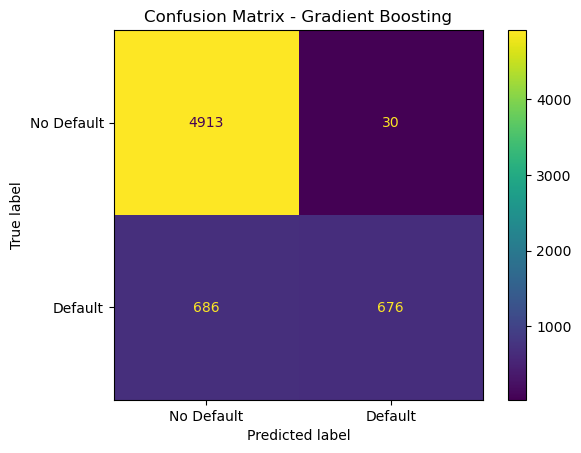

In [32]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                               f1_score, roc_auc_score, average_precision_score,
                               confusion_matrix, ConfusionMatrixDisplay)

results = []
for name, pipe in trained_models.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': average_precision_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df)

# Confusion matrix for best model
best_name = results_df.iloc[0]['Model']
best_model = trained_models[best_name]
cm = confusion_matrix(y_test, best_model.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=['No Default','Default']).plot()
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

## Credit-Risk Metrics & Threshold Optimization

    Threshold  Precision    Recall        F1  Approval_Rate  \
0        0.10   0.341503  0.920705  0.498212       0.417605   
1        0.15   0.463354  0.821586  0.592534       0.616971   
2        0.20   0.569389  0.732012  0.640540       0.722284   
3        0.25   0.658623  0.681351  0.669794       0.776527   
4        0.30   0.726220  0.644640  0.683003       0.808247   
5        0.35   0.798228  0.595448  0.682086       0.838858   
6        0.40   0.868571  0.558003  0.679481       0.861221   
7        0.45   0.915167  0.522761  0.665421       0.876606   
8        0.50   0.957507  0.496329  0.653772       0.888025   
9        0.55   0.981982  0.480176  0.644970       0.894370   
10       0.60   0.989011  0.462555  0.630315       0.898969   
11       0.65   0.998390  0.455213  0.625315       0.901507   
12       0.70   0.998347  0.443465  0.614133       0.904044   
13       0.75   1.000000  0.441263  0.612328       0.904679   
14       0.80   1.000000  0.436858  0.608074       0.90

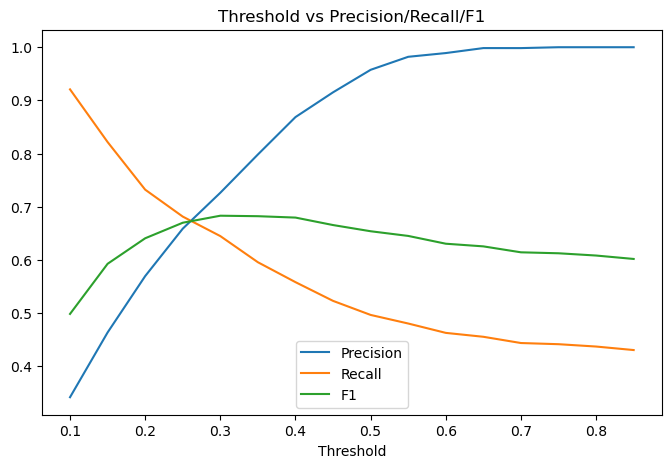

In [34]:
from sklearn.metrics import precision_recall_curve

best_model = trained_models['Gradient Boosting']
y_proba = best_model.predict_proba(X_test)[:,1]

thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    threshold_results.append({
        'Threshold': round(t,2),
        'Precision': precision_score(y_test, y_pred_t),
        'Recall': recall_score(y_test, y_pred_t),
        'F1': f1_score(y_test, y_pred_t),
        'Approval_Rate': 1 - y_pred_t.mean(),   # % predicted NOT high-risk
        'Flagged_High_Risk_Rate': y_pred_t.mean()
    })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df)

# Visualize the tradeoff
plt.figure(figsize=(8,5))
plt.plot(threshold_df['Threshold'], threshold_df['Precision'], label='Precision')
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], label='Recall')
plt.plot(threshold_df['Threshold'], threshold_df['F1'], label='F1')
plt.xlabel('Threshold'); plt.legend(); plt.title('Threshold vs Precision/Recall/F1')
plt.show()

## Hyperparameter Tuning

In [39]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [3, 4, 5],
    'clf__learning_rate': [0.05, 0.1, 0.2]
}

gb_pipe = Pipeline([('prep', preprocessor), ('clf', GradientBoostingClassifier(random_state=42))])

search = RandomizedSearchCV(gb_pipe, param_dist, n_iter=8, scoring='roc_auc',
                             cv=3, random_state=42, n_jobs=-1)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
tuned_model = search.best_estimator_

y_proba_tuned = tuned_model.predict_proba(X_test)[:,1]
print("Tuned ROC-AUC:", roc_auc_score(y_test, y_proba_tuned))
print("Original ROC-AUC:", roc_auc_score(y_test, y_proba))

Best params: {'clf__n_estimators': 300, 'clf__max_depth': 5, 'clf__learning_rate': 0.1}
Tuned ROC-AUC: 0.9104387669951395
Original ROC-AUC: 0.8793372196342267


## Calibration Check

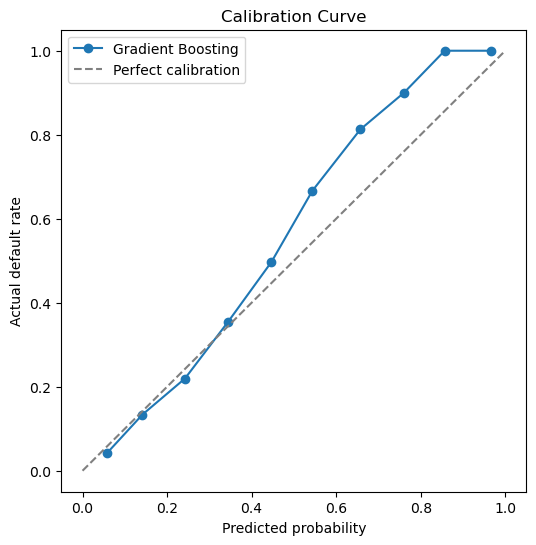

Brier score: 0.08854512657409457


In [40]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label='Gradient Boosting')
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Perfect calibration')
plt.xlabel('Predicted probability'); plt.ylabel('Actual default rate')
plt.legend(); plt.title('Calibration Curve')
plt.show()

from sklearn.metrics import brier_score_loss
print("Brier score:", brier_score_loss(y_test, y_proba))

# Credit Score Band

In [41]:
def risk_band(prob):
    if prob < 0.15:
        return "Low Risk"
    elif prob < 0.25:
        return "Medium Risk"
    elif prob < 0.45:
        return "High Risk"
    else:
        return "Very High Risk"

X_test_results = X_test.copy()
X_test_results['predicted_pd'] = y_proba
X_test_results['risk_band'] = X_test_results['predicted_pd'].apply(risk_band)
X_test_results['actual_default'] = y_test.values

X_test_results['risk_band'].value_counts()

risk_band
Low Risk          3890
Medium Risk       1006
Very High Risk     778
High Risk          631
Name: count, dtype: int64

## Lending Recommendation Layer

In [42]:
def lending_recommendation(band):
    mapping = {
        "Low Risk": "Consider approval, subject to lender policy",
        "Medium Risk": "Consider manual review",
        "High Risk": "Additional assessment required",
        "Very High Risk": "High-risk application; apply lender policy"
    }
    return mapping[band]

X_test_results['recommendation'] = X_test_results['risk_band'].apply(lending_recommendation)
X_test_results[['predicted_pd','risk_band','recommendation','actual_default']].head(10)

,predicted_pd,risk_band,recommendation,actual_default
14455,0.087674,Low Risk,"Consider approval, subject to lender policy",1
8701,0.174548,Medium Risk,Consider manual review,0
19804,0.938382,Very High Risk,High-risk application; apply lender policy,1
27252,0.074820,Low Risk,"Consider approval, subject to lender policy",0
5610,0.297920,High Risk,Additional assessment required,0
17487,0.068804,Low Risk,"Consider approval, subject to lender policy",0
23698,0.076655,Low Risk,"Consider approval, subject to lender policy",0
25856,0.005722,Low Risk,"Consider approval, subject to lender policy",0
22662,0.203989,Medium Risk,Consider manual review,0
17210,0.086220,Low Risk,"Consider approval, subject to lender policy",0


In [43]:
X_test_results.groupby('risk_band')['actual_default'].mean().sort_values()

risk_band
Low Risk          0.062468
Medium Risk       0.189861
High Risk         0.342314
Very High Risk    0.915167
Name: actual_default, dtype: float64

## SHAP

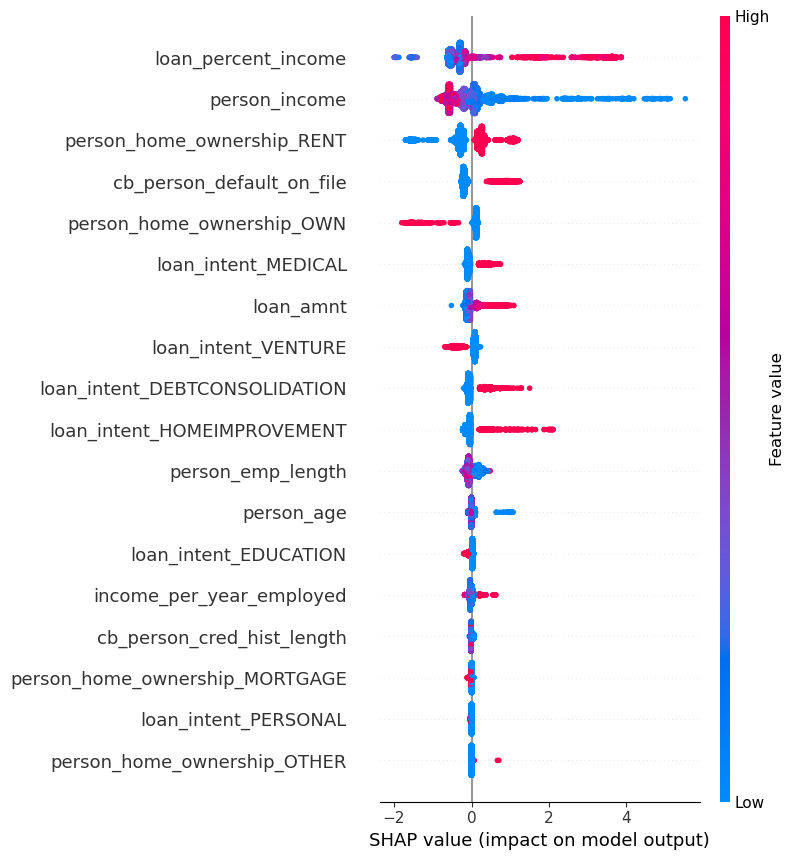

In [46]:
import shap

# Get the fitted classifier and preprocessed test data
clf = best_model.named_steps['clf']  # or tuned_model if you used tuning
X_test_transformed = best_model.named_steps['prep'].transform(X_test)

# Get feature names after one-hot encoding
feature_names = (numeric_features + 
    list(best_model.named_steps['prep'].named_transformers_['cat']
         .named_steps['onehot'].get_feature_names_out(categorical_features)))

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_transformed)

# Global feature importance
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=True)

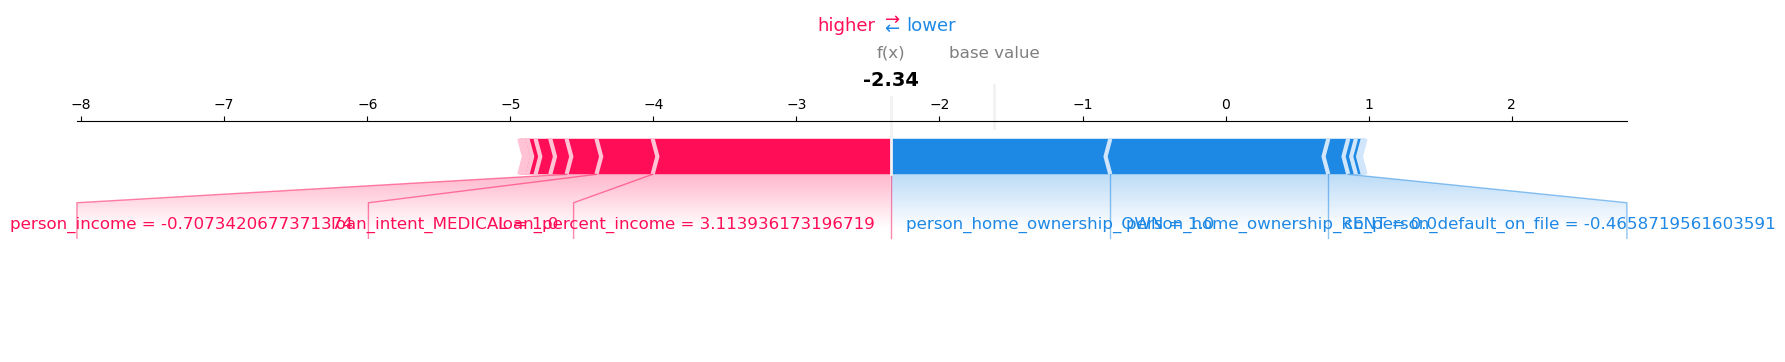

In [47]:
idx = 0  # pick any test applicant
shap.force_plot(explainer.expected_value, shap_values[idx], 
                 X_test_transformed[idx], feature_names=feature_names, matplotlib=True)

## Save

In [48]:
import joblib

joblib.dump(best_model, 'credit_risk_model.pkl')
X_test_results.to_csv('scored_applicants_sample.csv', index=False)
threshold_df.to_csv('threshold_analysis.csv', index=False)
results_df.to_csv('model_comparison.csv', index=False)

print("All artifacts saved ✅")

All artifacts saved ✅
